In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Información de Calidad de Dataset

In [2]:
df_movies = pd.read_csv('../data/netflix_movies_detailed_up_to_2025.csv')
df_tvshows = pd.read_csv('../data/netflix_tv_shows_detailed_up_to_2025.csv')

In [3]:
df_movies['type'] = 'Movie'
df_tvshows['type'] = 'TV Show'

In [4]:
df_combinado = pd.concat([df_movies, df_tvshows], join='inner', ignore_index=True)

In [5]:
df_combinado=df_combinado.drop(columns=['duration'])

In [6]:
df_combinado.info()

<class 'pandas.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       32000 non-null  int64  
 1   type          32000 non-null  str    
 2   title         32000 non-null  str    
 3   director      20903 non-null  str    
 4   cast          30639 non-null  str    
 5   country       29737 non-null  str    
 6   date_added    32000 non-null  str    
 7   release_year  32000 non-null  int64  
 8   rating        32000 non-null  float64
 9   genres        30919 non-null  str    
 10  language      32000 non-null  str    
 11  description   28662 non-null  str    
 12  popularity    32000 non-null  float64
 13  vote_count    32000 non-null  int64  
 14  vote_average  32000 non-null  float64
dtypes: float64(3), int64(3), str(9)
memory usage: 3.7 MB


In [7]:
df_combinado.duplicated(subset='show_id').sum()

np.int64(406)

In [8]:
duplicados = df_combinado[df_combinado.duplicated(subset=['title'], keep=False)]
duplicados_comparativa = duplicados.sort_values(by=['title'])
columnas_clave = ['show_id', 'title', 'type', 'release_year']
display(duplicados_comparativa[columnas_clave].head(20))

,show_id,title,type,release_year
10927,586032,1,Movie,2020
3401,217316,1,Movie,2013
24124,80719,100 días para enamorarse,TV Show,2018
25072,97881,100 días para enamorarse,TV Show,2019
5304,319337,13 Minutes,Movie,2015
11153,787723,13 Minutes,Movie,2021
17844,38527,19-2,TV Show,2011
20156,61546,19-2,TV Show,2014
21744,62459,1992,TV Show,2015
30865,225467,1992,TV Show,2024


In [9]:
duplicados = df_combinado[df_combinado.duplicated(subset=['show_id'], keep=False)]
duplicados_comparativa = duplicados.sort_values(by=['show_id'])
columnas_clave = ['show_id', 'title', 'type', 'release_year']
display(duplicados_comparativa.head(20))

,show_id,type,title,director,cast,country,date_added,release_year,rating,genres,language,description,popularity,vote_count,vote_average
24,18823,Movie,Clash of the Titans,Louis Leterrier,"Sam Worthington, Gemma Arterton, Mads Mikkelse...",United States of America,2010-03-26,2010,5.900,"Adventure, Fantasy, Action",en,"Born of a god but raised as a man, Perseus is ...",51.888,6308,5.900
16485,18823,TV Show,Growing Through Life,NaN,"Damian Lau Chung-Yan, Raymond Lam Fung, Cecili...",Hong Kong,2010-08-06,2010,0.000,Drama,cn,Growing Through Life is a 2010 TVB modern seri...,31.501,0,0.000
26967,30675,TV Show,Crackerjack!,NaN,"Mark Rhodes, Sam Nixon",United Kingdom,2020-01-17,2020,0.000,"Comedy, Family",en,Revival of the hit family entertainment show t...,22.478,0,0.000
130,30675,Movie,Planet Hulk,Sam Liu,"Rick D. Wasserman, Lisa Ann Beley, Mark Hildre...",United States of America,2010-02-02,2010,7.000,"Science Fiction, Animation, Action, Fantasy",en,When the Hulk's presence on Earth becomes too ...,18.537,491,7.000
16094,32612,TV Show,Check It Out! with Dr. Steve Brule,"Tim Heidecker, Eric Wareheim",John C. Reilly,United States of America,2010-05-16,2010,8.079,Comedy,en,"See Dr. Steve learn about restaurants, spend t...",145.220,63,8.079
588,32612,Movie,The Traveler,Michael Oblowitz,"John Cassini, Val Kilmer, Camille Sullivan, Dy...",United States of America,2010-11-15,2010,5.300,"Horror, Thriller",en,"On a dark Christmas Eve in a small town, the l...",6.597,104,5.300
416,32916,Movie,Scooby-Doo! Abracadabra-Doo,"Spike Brandt, Tony Cervone","Frank Welker, Matthew Lillard, Mindy Cohn, Gre...",United States of America,2010-02-16,2010,7.700,"Animation, Comedy, Family, Mystery, Fantasy",en,The gang goes on a trip to check on Velma's yo...,8.749,250,7.700
16338,32916,TV Show,Malparida,NaN,"Carina Zampini, Ximena Díaz, Gabriela Sari, Ju...",Argentina,2010-04-20,2010,4.200,Soap,es,Malparida is a 2010 Argentine telenovela aired...,54.835,2,4.200
16069,33217,TV Show,Young Justice,NaN,"Jesse McCartney, Khary Payton, Nolan North, Da...",United States of America,2010-11-26,2010,8.400,"Animation, Sci-Fi & Fantasy, Action & Adventure",en,Teenage superheroes strive to prove themselves...,148.156,1123,8.400
61,33217,Movie,Diary of a Wimpy Kid,Thor Freudenthal,"Zachary Gordon, Robert Capron, Steve Zahn, Dev...","United Kingdom, United States of America",2010-03-19,2010,6.200,"Comedy, Family",en,"Greg Heffley is headed for big things, but fir...",31.191,1613,6.200


In [10]:
df_combinado['show_id'] = df_combinado['show_id'].astype(str)

df_combinado['show_id'] = np.where(
    df_combinado['type'] == 'Movie',
    'mv' + df_combinado['show_id'],
    'tv' + df_combinado['show_id']
)

display(df_combinado[['show_id', 'title', 'type']].head())

,show_id,title,type
0,mv10192,Shrek Forever After,Movie
1,mv27205,Inception,Movie
2,mv12444,Harry Potter and the Deathly Hallows: Part 1,Movie
3,mv38757,Tangled,Movie
4,mv10191,How to Train Your Dragon,Movie


In [11]:
df_combinado = df_combinado.sort_values(by=['title', 'popularity'], ascending=[True, False])
columnas_criterio = ['title', 'release_year', 'type']
df_combinado = df_combinado.drop_duplicates(subset=columnas_criterio, keep='first')

In [12]:
df_combinado.duplicated(subset='show_id').sum()

np.int64(0)

In [13]:
df_tvshows = df_tvshows.sort_values(by=['title', 'popularity'], ascending=[True, False])
columnas_criterio = ['title', 'release_year', 'type']
df_tvshows = df_tvshows.drop_duplicates(subset=columnas_criterio, keep='first')

In [14]:
df_tvshows.duplicated(subset='show_id').sum()

np.int64(0)

In [15]:
df_tvshows['show_id'] = 'tv' + df_tvshows['show_id'].astype(str)
display(df_tvshows[['show_id', 'title', 'type']].head())

,show_id,title,type
15769,tv218510,#1 Happy Family USA,TV Show
8627,tv87813,#5règles,TV Show
6208,tv158475,#BOOS,TV Show
10354,tv98624,#FreeRayshawn,TV Show
5994,tv63206,#KOMTR,TV Show


In [16]:
df_movies['show_id'] = 'mv' + df_movies['show_id'].astype(str)
display(df_movies[['show_id', 'title', 'type']].head())

,show_id,title,type
0,mv10192,Shrek Forever After,Movie
1,mv27205,Inception,Movie
2,mv12444,Harry Potter and the Deathly Hallows: Part 1,Movie
3,mv38757,Tangled,Movie
4,mv10191,How to Train Your Dragon,Movie


In [17]:
df_combinado.to_csv('../data/dataset_combinado.csv', index=False, encoding='utf-8')

In [18]:
df_tvshows.to_csv('../data/dataset_tvshows.csv', index=False, encoding='utf-8')
df_movies.to_csv('../data/dataset_movies.csv', index=False, encoding='utf-8')

In [19]:
data = df_combinado
data.info()

<class 'pandas.DataFrame'>
Index: 31918 entries, 12961 to 26987
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       31918 non-null  str    
 1   type          31918 non-null  str    
 2   title         31918 non-null  str    
 3   director      20852 non-null  str    
 4   cast          30561 non-null  str    
 5   country       29662 non-null  str    
 6   date_added    31918 non-null  str    
 7   release_year  31918 non-null  int64  
 8   rating        31918 non-null  float64
 9   genres        30842 non-null  str    
 10  language      31918 non-null  str    
 11  description   28590 non-null  str    
 12  popularity    31918 non-null  float64
 13  vote_count    31918 non-null  int64  
 14  vote_average  31918 non-null  float64
dtypes: float64(3), int64(2), str(10)
memory usage: 3.9 MB


In [20]:
data.isnull().sum()

show_id             0
type                0
title               0
director        11066
cast             1357
country          2256
date_added          0
release_year        0
rating              0
genres           1076
language            0
description      3328
popularity          0
vote_count          0
vote_average        0
dtype: int64

In [21]:
data.duplicated().sum()

np.int64(0)

Existen valores faltantes en los campos director, cast, country, genres y description, los cuales serán tratados durante sus respectivos análisis. No se presentan valores duplicados.

# 2. Análisis Exploratorio Inicial

In [22]:
df_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  str    
 1   type          16000 non-null  str    
 2   title         16000 non-null  str    
 3   director      15868 non-null  str    
 4   cast          15796 non-null  str    
 5   country       15534 non-null  str    
 6   date_added    16000 non-null  str    
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  str    
 11  language      16000 non-null  str    
 12  description   15868 non-null  str    
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(4), str(10)
memo

## Análisis Univariado

### Budget y Revenue de Películas

In [23]:
df_movies['revenue'] = df_movies['revenue'].replace(0, np.nan)
df_movies['revenue'].isnull().sum()

np.int64(10355)

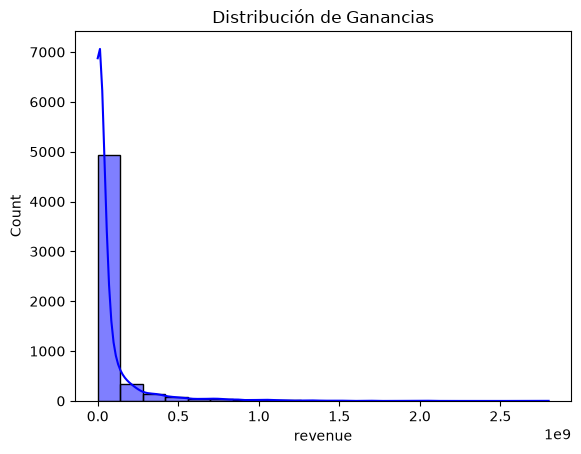

In [24]:
sns.histplot(
    data = df_movies,
    x = 'revenue',
    bins = 20,
    color = 'blue',
    kde = True

)

plt.title('Distribución de Ganancias')
plt.show()

In [25]:
df_movies['budget'] = df_movies['budget'].replace(0, np.nan)
df_movies['budget'].isnull().sum()

np.int64(11153)

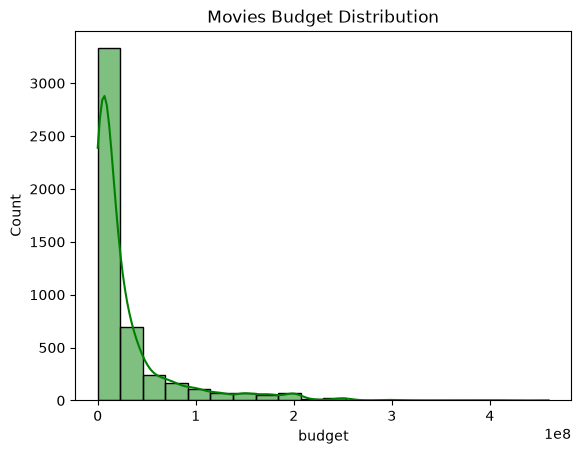

In [26]:
sns.histplot(
    data = df_movies,
    x = 'budget',
    bins = 20,
    color = 'green',
    kde = True
)

plt.title('Movies Budget Distribution')
plt.show()

La distribución del presupuesto presenta un fuerte sesgo a la derecha (asimetría positiva), lo que indica que la mayoría de las películas tienen un presupuesto de bajo a medio (cercano a la media), mientras que unas pocas cuentan con presupuestos muy elevados. Por su parte, la distribución de los ingresos está extremadamente sesgada a la derecha, ya que la mayor parte de las películas registran ganancias bajas y por debajo de la media, frente a un reducido número de producciones con una recaudación excepcionalmente alta.

### Top Países

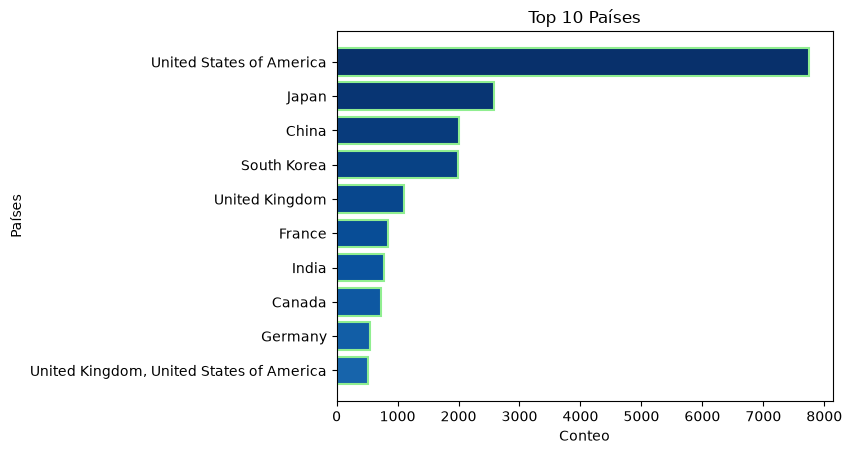

In [27]:
plt.barh(

        width = data['country'].value_counts().head(10).values,
        y= data['country'].value_counts().head(10).index,
        color = plt.cm.Blues(np.linspace(1, 0.8, 10)),
        linewidth = 1.5,
        edgecolor = 'lightgreen',

)

plt.title('Top 10 Países')
plt.xlabel('Conteo')
plt.gca().invert_yaxis()
plt.ylabel('Países')
plt.show()

Estados Unidos concentra la mayor cantidad de películas y tv shows en el conjunto de datos, seguido por Japón y China por un amplio margen. Asimismo, existe una cantidad significativa de valores faltantes.

### Top Lenguajes

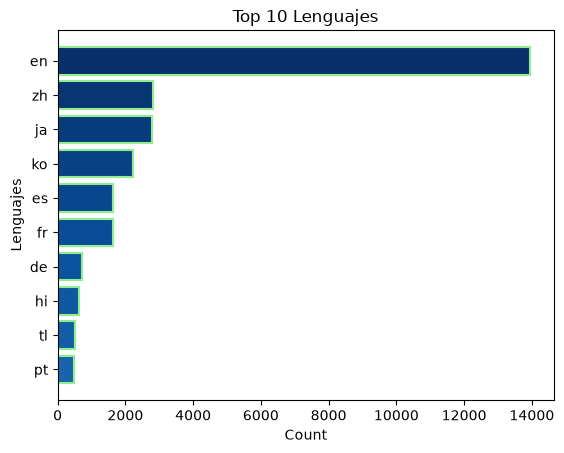

In [28]:
plt.barh(
        width = data['language'].value_counts().head(10).values,
        y= data['language'].value_counts().head(10).index,
        color = plt.cm.Blues(np.linspace(1, 0.8, 10)),
        linewidth = 1.5,
        edgecolor = 'lightgreen',

)

plt.title('Top 10 Lenguajes')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.ylabel('Lenguajes')
plt.show()

El conjunto de datos está fuertemente dominado por películas en inglés, seguidas por las películas en chino y japonés por un amplio margen.

### Producciones por Rating

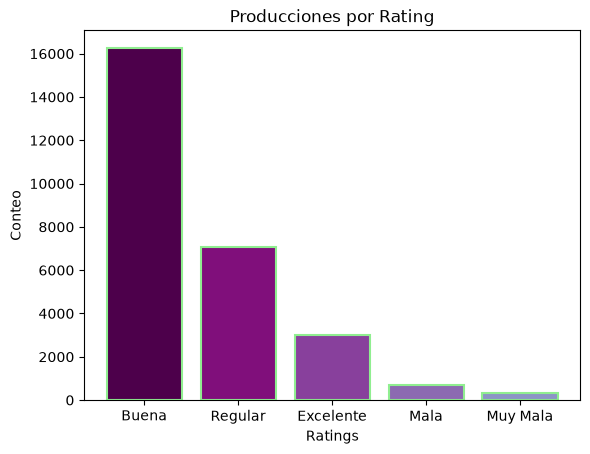

In [29]:
data['rating_category'] = pd.cut(data['rating'],
                                 bins = [0, 2, 4, 6, 8, 10],
                                 labels = ['Muy Mala', 'Mala', 'Regular', 'Buena', 'Excelente'])

plt.bar(
    x = data['rating_category'].value_counts().index,
    height = data['rating_category'].value_counts().values,
    color = plt.cm.BuPu(np.linspace(1, 0.5, 5)),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)

plt.title('Producciones por Rating')
plt.xlabel('Ratings')
plt.ylabel('Conteo')
plt.show()

La mayoría de las producciones tiene una calificación por encima de Regular, muy pocas están calificadas como malas o muy malas.

### Top Géneros

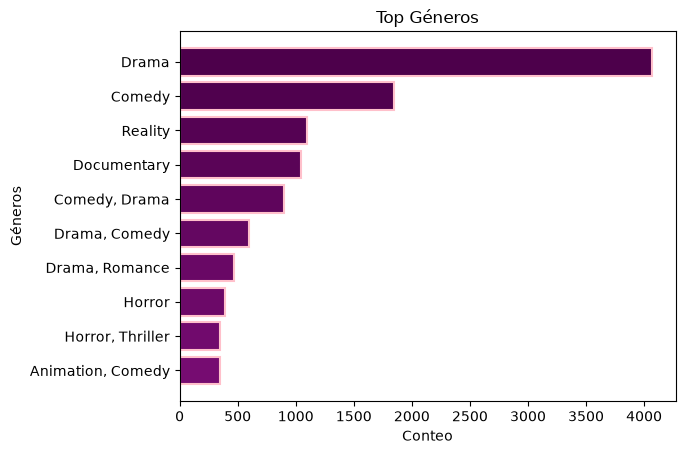

In [30]:
plt.barh(
     y = data['genres'].value_counts().head(10).index,
     width = data['genres'].value_counts().head(10).values,
     color = plt.cm.BuPu(np.linspace(1, 0.9, 10)),
     linewidth = 1.5,
     edgecolor = 'pink'
)

plt.title('Top Géneros')
plt.xlabel('Conteo')
plt.ylabel('Géneros')
plt.gca().invert_yaxis()
plt.show()

El género de drama domina el conjunto de datos por un amplio margen. Por su parte, la comedia y la animación presentan una representación moderada.

## Análisis Bivariado

### País vs Rating

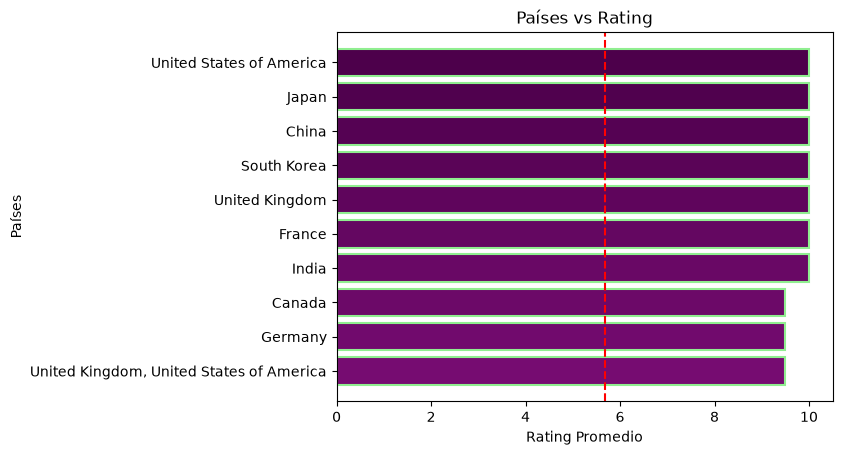

In [31]:
plt.barh(
    y = data.groupby('country')['rating'].count().nlargest(10).index,
    width = data.groupby('country')['rating'].mean().nlargest(10).values,
    color = plt.cm.BuPu(np.linspace(1, 0.9, 10)),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)

plt.axvline(x = data['rating'].mean(), color = 'red', linestyle = '--', linewidth = 1.5)
plt.title('Países vs Rating')
plt.ylabel('Países')
plt.xlabel('Rating Promedio')
plt.gca().invert_yaxis()
plt.show()

Estados Unidos y Japón concentran la mayor cantidad de películas con las calificaciones más altas, alcanzando una puntuación media perfecta.

### Género vs Popularidad

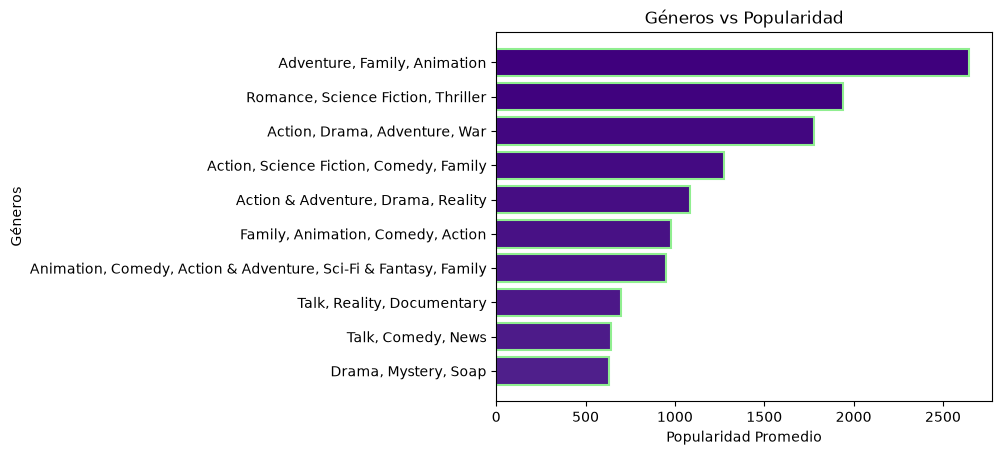

In [32]:
plt.barh(
    y = data.groupby('genres')['popularity'].mean().sort_values().nlargest(10).index,
    width = data.groupby('genres')['popularity'].mean().sort_values().nlargest(10).values,
    color = plt.cm.Purples(np.linspace(1, 0.9, 10)),
    linewidth = 1.5,
    edgecolor = 'lightgreen',
      )

plt.title('Géneros vs Popularidad')
plt.ylabel('Géneros')
plt.xlabel('Popularidad Promedio')
plt.gca().invert_yaxis()
plt.show()

Ciencia Ficción, Acción y Aventura son los géneros más populares.

### Géneros vs Ratings

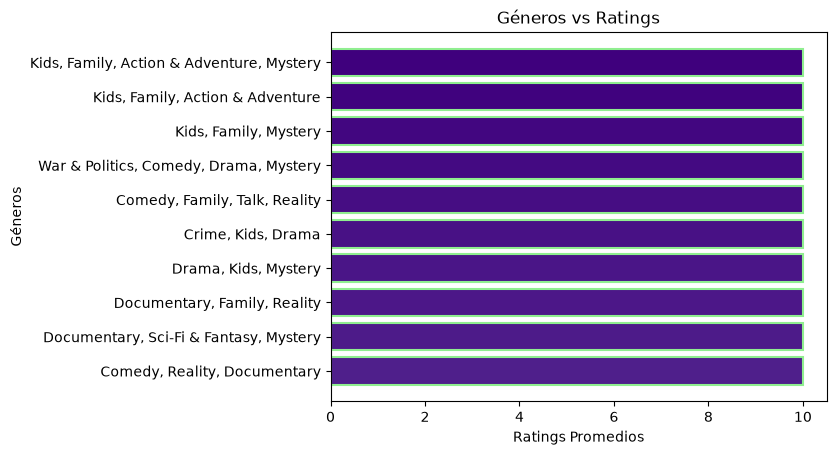

In [33]:
plt.barh(
    y = data.groupby('genres')['rating'].mean().sort_values().nlargest(10).index,
    width = data.groupby('genres')['rating'].mean().sort_values().nlargest(10).values,
    color = plt.cm.Purples(np.linspace(1, 0.9, 10)),
    linewidth = 1.5,
    edgecolor = 'lightgreen',
      )

plt.title('Géneros vs Ratings')
plt.ylabel('Géneros')
plt.xlabel('Ratings Promedios')
plt.gca().invert_yaxis()
plt.show()

# Limpieza y Transformación Exclusiva de Movies Dataset

In [34]:
# Cargar el dataset original
df = pd.read_csv('../data/netflix_movies_detailed_up_to_2025.csv')

In [35]:
# Eliminar columnas que no aportan al análisis financiero ni visual
columnas_a_eliminar = ['duration', 'description']
df.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

print("Columnas eliminadas con éxito.")

Columnas eliminadas con éxito.


In [36]:
# Filtrar registros con presupuesto o ingresos en cero
# Usamos .copy() para crear un DataFrame independiente y evitar advertencias (SettingWithCopyWarning)
df_clean = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()

print(f"Tamaño del dataset después de aplicar la Regla 6: {df_clean.shape}")

Tamaño del dataset después de aplicar la Regla 6: (3540, 16)


In [37]:
# Imputar valores nulos en variables categóricas
cols_categoricas = ['country', 'director', 'genres', 'cast']

for col in cols_categoricas:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Desconocido')

print("Valores nulos imputados por 'Desconocido'.")

Valores nulos imputados por 'Desconocido'.


In [38]:
# Transformar fechas y crear la métrica de ROI
# Convertir date_added a formato datetime
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')

# Calcular el Retorno de Inversión (ROI)
# Un ROI > 1 significa que generó ganancias
df_clean['ROI'] = df_clean['revenue'] / df_clean['budget']

# Redondear el ROI a 2 decimales para que sea amigable visualmente
df_clean['ROI'] = df_clean['ROI'].round(2)

print("Formatos ajustados y ROI calculado.")

Formatos ajustados y ROI calculado.


In [39]:
# Exportar el dataset limpio
nombre_archivo_salida = '../data/netflix_movies_financials_clean.csv'
df_clean.to_csv(nombre_archivo_salida, index=False, encoding='utf-8')

print(f"Dataset exportado exitosamente como: {nombre_archivo_salida}")

Dataset exportado exitosamente como: ../data/netflix_movies_financials_clean.csv
